# Exploratory Data Analysis (EDA) #

### Load Dataset ###

In [4]:
import pandas as pd

df = pd.read_csv("cleaned_real_estate.csv")
df.head()

,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt
0,0.117684,0.227638,0.333333,0.003587,0.333333,0.0,0.256978
1,0.089664,0.401663,0.666667,0.003587,0.333333,0.0,0.117963
2,0.075094,0.178326,0.000000,0.436827,0.000000,0.0,0.201682
3,0.162516,0.479931,0.666667,0.712919,0.333333,0.0,0.181380
4,0.200624,0.686353,0.666667,0.790241,0.666667,0.0,0.159936


### Basic Understanding (EDA) ###

In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1112664 entries, 0 to 1112663
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Price           1112664 non-null  float64
 1   Area_SqFt       1112664 non-null  float64
 2   Bedrooms        1112664 non-null  float64
 3   Location        1112664 non-null  float64
 4   Bathrooms       1112664 non-null  float64
 5   Source          1112664 non-null  float64
 6   Price_Per_SqFt  1112664 non-null  float64
dtypes: float64(7)
memory usage: 59.4 MB


,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt
count,1.112664e+06,1.112664e+06,1.112664e+06,1.112664e+06,1.112664e+06,1112664.0,1.112664e+06
mean,3.843087e-01,4.795382e-01,3.885417e-01,4.996882e-01,4.291952e-01,0.0,4.341523e-01
std,2.026662e-01,1.805744e-01,2.599825e-01,2.868404e-01,2.607958e-01,0.0,1.944684e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00
25%,2.297645e-01,3.408830e-01,3.333333e-01,2.478506e-01,3.333333e-01,0.0,2.974279e-01
50%,3.580963e-01,4.512615e-01,3.333333e-01,5.028184e-01,3.333333e-01,0.0,4.062867e-01
75%,5.043610e-01,5.934633e-01,6.666667e-01,7.506121e-01,6.666667e-01,0.0,5.497832e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.0,1.000000e+00


### Missing Values ###

In [6]:
df.isnull().sum()

Price             0
Area_SqFt         0
Bedrooms          0
Location          0
Bathrooms         0
Source            0
Price_Per_SqFt    0
dtype: int64

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt
0,0.117684,0.227638,0.333333,0.003587,0.333333,0.0,0.256978
1,0.089664,0.401663,0.666667,0.003587,0.333333,0.0,0.117963
2,0.075094,0.178326,0.000000,0.436827,0.000000,0.0,0.201682
3,0.162516,0.479931,0.666667,0.712919,0.333333,0.0,0.181380
4,0.200624,0.686353,0.666667,0.790241,0.666667,0.0,0.159936
...,...,...,...,...,...,...,...
1112659,0.431509,0.438647,0.666667,0.750214,0.333333,0.0,0.523473
1112660,0.380961,0.760894,0.666667,0.750214,0.333333,0.0,0.275296
1112661,0.403377,0.995986,0.666667,0.750214,0.333333,0.0,0.225099
1112662,0.392281,0.427179,0.333333,0.750214,0.333333,0.0,0.487664


### Data Distribution ###

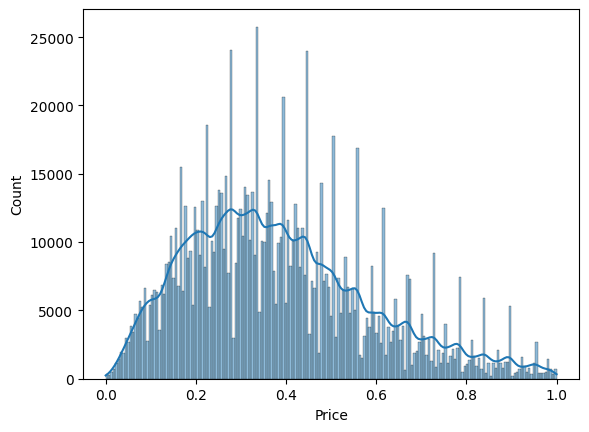

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'], kde=True)
plt.show()

### Correlation ###

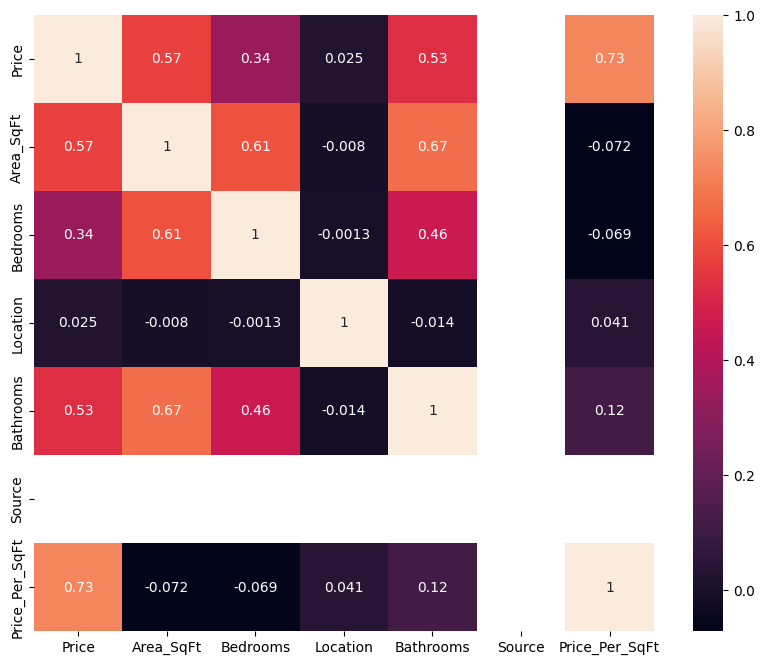

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

## Feature Engineering ##

In [13]:
df['Price_per_sqft'] = df['Price'] / df['Area_SqFt']

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])

In [16]:
df['Area_Category'] = pd.cut(df['Area_SqFt'],
                            bins=[0,1000,2000,5000],
                            labels=['Small','Medium','Large'])

## Feature Selection ##

In [18]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.corr()['Price'].sort_values(ascending=False)

Price             1.000000
Price_Per_SqFt    0.731108
Price_per_sqft    0.680362
Area_SqFt         0.574838
Bathrooms         0.527965
Bedrooms          0.339480
Location          0.024703
Source                 NaN
Name: Price, dtype: float64

In [20]:
df.head()


,Price,Area_SqFt,Bedrooms,Location,Bathrooms,Source,Price_Per_SqFt,Price_per_sqft,Area_Category
0,0.117684,0.227638,0.333333,0.003587,0.333333,0.0,0.256978,0.516981,Small
1,0.089664,0.401663,0.666667,0.003587,0.333333,0.0,0.117963,0.223232,Small
2,0.075094,0.178326,0.000000,0.436827,0.000000,0.0,0.201682,0.421105,Small
3,0.162516,0.479931,0.666667,0.712919,0.333333,0.0,0.181380,0.338624,Small
4,0.200624,0.686353,0.666667,0.790241,0.666667,0.0,0.159936,0.292304,Small
